# Multi-area EI network — per-area DMFT statistics from simulation

Ground-truth simulation of finite randomly-generated multi-area EI networks to measure the per-area statistics that the DMFT predicts (useful for checking the **asymmetric** case, which is hard analytically).

Dynamics: $\dot{x} = -x + W\,\phi(x)$.  We warm up for `T_warmup`, take that state as $\tau=0$, then record for `T_record` and measure, per area $a$:

- $\mu_a(\tau)=\langle x_i\rangle_i$ — mean current
- $\langle\phi\rangle_a(\tau)=\langle\phi(x_i)\rangle_i$ — mean rate
- $q_a(\tau)=\langle\phi^2\rangle_i-\langle\phi\rangle_i^2$ — rate variance
- $\Delta_a(\tau)$ — **current** autocorrelation (connected)
- $C_a(\tau)$ — **rate** autocorrelation

Autocorrelations are computed two ways: **single-reference** (vs the $\tau=0$ state, over the full window) and **stationary-averaged** (over reference times, lags up to ``). Heavy results are saved under `Data/multiarea_dynamics/<run_name>/` so the plots can be redrawn without re-simulating.

## 1. Core machinery (reused from the case-study notebook)

In [1]:
# ============================================================
#  Core machinery (reused verbatim from
#  Multi-area_circuit_EI_sparse_case_study.ipynb)
#  Micro-parameters per area + sparse fixed-in-degree EI connectivity.
# ============================================================
from dataclasses import dataclass, asdict, replace
from typing import Any, Dict, Optional, Tuple, Iterable
import json
import numpy as np
from pathlib import Path
from scipy.sparse import csr_matrix, diags, eye
import matplotlib.pyplot as plt


@dataclass(frozen=True)
class AreaParams:
    """
    Parameters for one brain area.

    N      : number of neurons in this area
    s      : local sparsity, C_i = round(s * N) local recurrent inputs per neuron
    f_exc  : fraction of excitatory neurons; N_E = round(f_exc * N), N_I = N - N_E
    J_exc  : local excitatory synaptic weight
    g_inh  : local inhibitory strength ratio; inhibitory weight = - g_inh * J_exc
    """
    N: int
    s: float
    f_exc: float
    J_exc: float
    g_inh: float


@dataclass(frozen=True)
class MultiAreaParams:
    """Parameters for the full multi-area network (see case-study notebook)."""
    areas: Tuple[AreaParams, ...]
    s_cross: np.ndarray         # (A, A): s_cross[src, tgt], only E neurons in src project
    J_cross: np.ndarray         # (A, A): excitatory weight src -> tgt
    allow_autapses: bool
    activation: str             # "tanh" or "threshold_linear"
    phi_max: float
    gamma: float
    dt: float
    T: float
    seed: int = 0


def phi(x: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    """Rate nonlinearity (elementwise; works on scalars / 1-D / 2-D arrays)."""
    if p.activation == "tanh":
        return np.tanh(x) + 1.0
    if p.activation == "threshold_linear":
        y = np.maximum(0.0, (x + p.gamma))
        if np.isfinite(p.phi_max):
            y = np.minimum(p.phi_max, y)
        return y
    raise ValueError(f"Unknown activation = {p.activation}")


def phi_prime(x: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    """Derivative of the activation function."""
    x = np.asarray(x, dtype=float)
    if p.activation == "tanh":
        y = np.tanh(x)
        return 1.0 - y * y
    if p.activation == "threshold_linear":
        g = ((x + p.gamma) >= 0.0).astype(float)
        if np.isfinite(p.phi_max):
            g = g * ((x + p.gamma) < p.phi_max)
        return g
    raise ValueError(f"Unknown activation = {p.activation}")


def population_info(p: MultiAreaParams) -> Dict[str, Any]:
    """Index bookkeeping for the multi-area EI network.
    Population order: (area0,E),(area0,I),(area1,E),(area1,I),..."""
    pops = []
    pop_sizes = []
    pop_slices = {}
    area_slices = {}
    area_stats = []

    start = 0
    for area_id, ap in enumerate(p.areas):
        N_E = int(round(ap.f_exc * ap.N))
        N_I = ap.N - N_E
        if N_E < 0 or N_I < 0:
            raise ValueError(f"Area {area_id}: invalid E/I split")

        C = int(round(ap.s * ap.N))
        C_E = int(round(ap.f_exc * C))
        C_I = C - C_E

        e_slice = slice(start, start + N_E)
        pops.append((area_id, "E"))
        pop_slices[(area_id, "E")] = e_slice
        pop_sizes.append(N_E)
        start += N_E

        i_slice = slice(start, start + N_I)
        pops.append((area_id, "I"))
        pop_slices[(area_id, "I")] = i_slice
        pop_sizes.append(N_I)
        start += N_I

        area_slices[area_id] = slice(e_slice.start, i_slice.stop)
        area_stats.append({
            "area_id": area_id, "N": ap.N, "N_E": N_E, "N_I": N_I,
            "C": C, "C_E": C_E, "C_I": C_I,
            "J_E": ap.J_exc, "J_I": -ap.g_inh * ap.J_exc,
        })

    return {
        "pops": pops,
        "pop_sizes": np.asarray(pop_sizes, dtype=int),
        "N_total": start,
        "pop_slices": pop_slices,
        "area_slices": area_slices,
        "area_stats": area_stats,
    }


def _validate_params(p: MultiAreaParams) -> None:
    A = len(p.areas)
    if p.s_cross.shape != (A, A):
        raise ValueError(f"s_cross must have shape ({A}, {A})")
    if p.J_cross.shape != (A, A):
        raise ValueError(f"J_cross must have shape ({A}, {A})")
    for area_id, ap in enumerate(p.areas):
        if ap.N <= 0:
            raise ValueError(f"Area {area_id}: N must be positive")
        if not (0.0 <= ap.s <= 1.0):
            raise ValueError(f"Area {area_id}: s must be in [0, 1]")
        if not (0.0 <= ap.f_exc <= 1.0):
            raise ValueError(f"Area {area_id}: f_exc must be in [0, 1]")
    if np.any(p.s_cross < 0.0) or np.any(p.s_cross > 1.0):
        raise ValueError("All s_cross entries must be in [0, 1]")


def _candidate_pool(indices: np.ndarray, target_idx: int, allow_autapses: bool) -> np.ndarray:
    if allow_autapses or len(indices) == 0:
        return indices
    if indices[0] <= target_idx <= indices[-1]:
        return indices[indices != target_idx]
    return indices


def build_multi_area_connectivity(p: MultiAreaParams) -> Tuple[csr_matrix, Dict[str, Any]]:
    """Build the full sparse recurrent matrix W (random fixed-in-degree EI network)."""
    _validate_params(p)
    rng = np.random.default_rng(p.seed)
    info = population_info(p)

    A = len(p.areas)
    N_total = info["N_total"]
    pop_slices = info["pop_slices"]
    area_stats = info["area_stats"]

    rows, cols, data = [], [], []

    for tgt_area in range(A):
        stat_t = area_stats[tgt_area]
        tgt_all = np.arange(info["area_slices"][tgt_area].start,
                            info["area_slices"][tgt_area].stop)
        tgt_exc = np.arange(pop_slices[(tgt_area, "E")].start,
                            pop_slices[(tgt_area, "E")].stop)
        tgt_inh = np.arange(pop_slices[(tgt_area, "I")].start,
                            pop_slices[(tgt_area, "I")].stop)

        C_E_local = stat_t["C_E"]
        C_I_local = stat_t["C_I"]
        w_E_local = stat_t["J_E"]
        w_I_local = stat_t["J_I"]

        for i_tgt in tgt_all:
            exc_pool = _candidate_pool(tgt_exc, i_tgt, p.allow_autapses)
            inh_pool = _candidate_pool(tgt_inh, i_tgt, p.allow_autapses)

            if C_E_local > len(exc_pool):
                raise ValueError(f"Area {tgt_area}: local C_E={C_E_local} exceeds "
                                 f"available local excitatory candidates={len(exc_pool)}")
            if C_I_local > len(inh_pool):
                raise ValueError(f"Area {tgt_area}: local C_I={C_I_local} exceeds "
                                 f"available local inhibitory candidates={len(inh_pool)}")

            if C_E_local > 0:
                pre_exc = rng.choice(exc_pool, size=C_E_local, replace=False)
                rows.extend([i_tgt] * C_E_local)
                cols.extend(pre_exc.tolist())
                data.extend([w_E_local] * C_E_local)

            if C_I_local > 0:
                pre_inh = rng.choice(inh_pool, size=C_I_local, replace=False)
                rows.extend([i_tgt] * C_I_local)
                cols.extend(pre_inh.tolist())
                data.extend([w_I_local] * C_I_local)

            for src_area in range(A):
                if src_area == tgt_area:
                    continue
                src_exc = np.arange(pop_slices[(src_area, "E")].start,
                                    pop_slices[(src_area, "E")].stop)
                if len(src_exc) == 0:
                    continue
                s_ij = float(p.s_cross[src_area, tgt_area])
                if s_ij <= 0.0:
                    continue
                C_cross = int(round(s_ij * len(src_exc)))
                if C_cross == 0:
                    continue
                if C_cross > len(src_exc):
                    raise ValueError(f"Cross ({src_area}->{tgt_area}): C_cross={C_cross} "
                                     f"exceeds source excitatory pool={len(src_exc)}")
                pre_cross = rng.choice(src_exc, size=C_cross, replace=False)
                w_cross = float(p.J_cross[src_area, tgt_area])
                rows.extend([i_tgt] * C_cross)
                cols.extend(pre_cross.tolist())
                data.extend([w_cross] * C_cross)

    W = csr_matrix(
        (np.asarray(data, dtype=float),
         (np.asarray(rows, dtype=int), np.asarray(cols, dtype=int))),
        shape=(N_total, N_total),
    )
    meta = {
        "N_total": N_total, "pops": info["pops"], "pop_sizes": info["pop_sizes"],
        "pop_slices": pop_slices, "area_slices": info["area_slices"],
        "area_stats": area_stats, "nnz": W.nnz,
    }
    return W, meta


print("Core machinery loaded.")

Core machinery loaded.


## 2. Parameters — edit here

In [6]:
# ============================================================
#  Parameters  (EDIT HERE)
# ============================================================
#  Default: an ASYMMETRIC 2-area EI network (the case the DMFT theory
#  struggles with). Bounded activation (finite phi_max) guarantees the
#  network cannot diverge, so we get fluctuating -- not exploding -- activity.
#  Flip SMOKE_TEST to True for a fast end-to-end sanity run.
#  Alternatively, drop in one of the make_case(...) presets from the
#  case-study notebook instead of building `p` by hand.
# ============================================================

SMOKE_TEST = False   # True -> tiny network, short time, 2 seeds (seconds, for sanity)

DATA_ROOT = Path("Data/multiarea_dynamics")

if SMOKE_TEST:
    N_area            = 400
    T_warmup          = 2.0
    T_record          = 4.0
    dt                = 0.02
    dt_rec            = 0.10
               = 1.0
    n_sample_autocorr = 100
    n_realizations    = 2
    run_name          = "smoke_test"
else:
    N_area            = 8000      # neurons PER area
    T_warmup          = 2000.0     # discard transient (seconds); state here becomes tau = 0
    T_record          = 2000.0     # record statistics for this long (seconds)
    dt                = 0.01      # Euler step
    dt_rec            = 0.05      # store statistics every dt_rec seconds
               = 200.0      # max lag for the stationary-averaged autocorrelation
    n_sample_autocorr = 2000      # neurons/area subsampled for stationary autocorr (memory)
    n_realizations    = 10        # number of random seeds to average over
    run_name          = "asym_2area_8000"

# ---- micro-parameters per area (ASYMMETRIC: area 1 has stronger local E) ----
#  Fluctuating (chaotic) activity needs the random-coupling order parameter
#      M_random[a,a] = J_exc^2 * (C_E + g_inh^2 * C_I),   C_E = round(f_exc*s*N), C_I = C-C_E
#  to be ~> 1; otherwise the area relaxes to a (possibly saturated) fixed point.
#  With s=0.05, N=2000, f_exc=0.8, g_inh=4.5: C_E=80, C_I=20, so J_exc~0.05 gives
#  M_random ~ 1.2 (mildly chaotic). The mean is inhibition-stabilized
#  (M_struct[a,a]=J_exc*(C_E - g_inh*C_I) < 0), so currents stay bounded.
#  Turn the dial here (J_exc up / g_inh down) to move between regimes.
areas = (
    AreaParams(N=N_area, s=0.0125, f_exc=0.8, J_exc=0.055, g_inh=4.5),
    AreaParams(N=N_area, s=0.0125, f_exc=0.8, J_exc=0.055, g_inh=4.5),
)
A = len(areas)
NE = [int(round(a.f_exc * a.N)) for a in areas]   # excitatory count per area

# ---- asymmetric cross-area coupling (area0 -> area1 strong, area1 -> area0 weak) ----
s_cross = np.zeros((A, A))
J_cross = np.zeros((A, A))
s_cross[0, 1] = 40.0 / NE[0]; J_cross[0, 1] = 0.040
s_cross[1, 0] = 40.0 / NE[1]; J_cross[1, 0] = 0.020

p = MultiAreaParams(
    areas=areas,
    s_cross=s_cross,
    J_cross=J_cross,
    allow_autapses=False,
    activation="threshold_linear",
    phi_max=np.inf,          # finite -> activity is bounded and cannot diverge
    gamma=0.5,
    dt=dt,
    T=T_warmup + T_record,
    seed=0,
)

# kwargs forwarded to simulate_and_measure (seed is varied per realization)
sim_kwargs = dict(
    T_warmup=T_warmup,
    T_record=T_record,
    dt_rec=dt_rec,
    =,
    n_sample_autocorr=n_sample_autocorr,
    init_mode="small_normal",
    verbose=True,
)

print(f"run_name = {run_name!r}  (SMOKE_TEST={SMOKE_TEST})")
print(f"areas: N/area={N_area}, A={A}, "
      f"J_exc={[a.J_exc for a in areas]}, J_cross[0->1]={J_cross[0,1]}, J_cross[1->0]={J_cross[1,0]}")
print(f"warmup={T_warmup}s, record={T_record}s, dt={dt}, dt_rec={dt_rec}, "
      f"={}s, n_realizations={n_realizations}")

run_name = 'asym_2area_8000'  (SMOKE_TEST=False)
areas: N/area=8000, A=2, J_exc=[0.055, 0.055], J_cross[0->1]=0.04, J_cross[1->0]=0.02
warmup=2000.0s, record=2000.0s, dt=0.01, dt_rec=0.05, =200.0s, n_realizations=10


## 3. Simulation + statistics + save/load helpers

In [3]:
# ============================================================
#  Simulate dx/dt = -x + W @ phi(x), warm up, then record per-area statistics.
#  tau = 0 is the state at the end of warmup.
# ============================================================

def simulate_and_measure(
    p: MultiAreaParams,
    seed_init: int = 0,
    T_warmup: float = 2000.0,
    T_record: float = 2000.0,
    dt_rec: float = 0.05,
    : float = 200.0,
    n_sample_autocorr: int = 2000,
    init_mode: str = "small_normal",
    init_current_scale: float = 0.5,
    init_rate_low: float = 0.05,
    init_rate_high: float = 0.95,
    W: Optional[csr_matrix] = None,
    verbose: bool = True,
):
    """
    Returns (result, meta) where result is a dict of compact arrays:

      tau        (n_rec,)        recording times, tau=0 at warmup end
      mu         (n_rec, A)      mu_a(tau)      = mean_i x_i           (mean current)
      phi_mean   (n_rec, A)      <phi>_a(tau)   = mean_i phi(x_i)      (mean rate)
      q          (n_rec, A)      q_a(tau)       = mean_i phi^2 - (mean_i phi)^2  (rate variance)
      delta_sr   (n_rec, A)      single-ref CURRENT autocorr (connected) vs reference at tau=0
      C_sr       (n_rec, A)      single-ref RATE    autocorr (raw)       vs reference at tau=0
      tau_lag    (n_lag+1,)      lags for the stationary-averaged autocorr
      delta_stat (n_lag+1, A)    stationary-avg CURRENT autocorr (connected), over reference times
      C_stat     (n_lag+1, A)    stationary-avg RATE    autocorr (raw),       over reference times
      A, dt_rec, N_a             bookkeeping
    """
    dt = p.dt
    if W is None:
        W, meta = build_multi_area_connectivity(p)
    else:
        info0 = population_info(p)
        meta = {"N_total": info0["N_total"], "area_slices": info0["area_slices"]}

    N = W.shape[0]
    A = len(p.areas)
    info = population_info(p)
    area_slices = info["area_slices"]
    area_idx = [np.arange(area_slices[a].start, area_slices[a].stop) for a in range(A)]
    N_a = np.array([len(ix) for ix in area_idx], dtype=int)

    rng = np.random.default_rng(seed_init)

    # ---- initial state ----
    if init_mode == "small_normal":
        x = 1e-1 * rng.standard_normal(N)
    elif init_mode == "normal_current":
        x = init_current_scale * rng.standard_normal(N)
    elif init_mode == "uniform_current":
        x = rng.uniform(-init_current_scale, init_current_scale, size=N)
    elif init_mode == "uniform_rate":
        if not np.isfinite(p.phi_max):
            raise ValueError("init_mode='uniform_rate' requires finite phi_max.")
        r0 = rng.uniform(init_rate_low * p.phi_max, init_rate_high * p.phi_max, size=N)
        x = r0 - p.gamma
    else:
        raise ValueError(f"Unknown init_mode={init_mode!r}")

    # ---- warmup (no recording) ----
    n_warm = int(round(T_warmup / dt))
    for k in range(n_warm):
        x = x + dt * (-x + W @ phi(x, p))
        if not np.all(np.isfinite(x)):
            raise RuntimeError(f"State diverged during warmup at step {k}.")
    if verbose:
        print(f"  warmup done ({n_warm} steps); max|x|={np.max(np.abs(x)):.3g}")

    # ---- recording setup ----
    rec_every = max(1, int(round(dt_rec / dt)))
    dt_rec_eff = rec_every * dt
    n_rec_steps = int(round(T_record / dt))
    n_rec = n_rec_steps // rec_every + 1          # include the tau=0 frame

    tau = np.arange(n_rec) * dt_rec_eff
    mu = np.empty((n_rec, A))
    phi_mean = np.empty((n_rec, A))
    q = np.empty((n_rec, A))
    delta_sr = np.empty((n_rec, A))
    C_sr = np.empty((n_rec, A))

    # reference frame (tau = 0)
    x_ref = x.copy()
    r_ref = phi(x_ref, p)
    mu_ref = np.array([x_ref[area_slices[a]].mean() for a in range(A)])

    # subsample (per area) for the stationary-averaged autocorrelation
    sample_idx_list = []
    for a in range(A):
        ix = area_idx[a]
        n_pick = min(n_sample_autocorr, len(ix))
        sample_idx_list.append(rng.choice(ix, size=n_pick, replace=False))
    sample_idx = np.concatenate(sample_idx_list)
    sample_bounds = np.cumsum([0] + [len(s) for s in sample_idx_list])
    x_buf = np.empty((n_rec, len(sample_idx)))    # transient buffer (discarded after)

    def _record(k, xk):
        rk = phi(xk, p)
        for a in range(A):
            sl = area_slices[a]
            xa = xk[sl]; ra = rk[sl]
            ma = xa.mean()
            mu[k, a] = ma
            phi_mean[k, a] = ra.mean()
            q[k, a] = float((ra * ra).mean() - ra.mean() ** 2)
            delta_sr[k, a] = float(((x_ref[sl] - mu_ref[a]) * (xa - ma)).mean())
            C_sr[k, a] = float((r_ref[sl] * ra).mean())
        x_buf[k] = xk[sample_idx]

    _record(0, x)            # tau = 0 frame (x == x_ref here)
    kk = 0
    for step in range(1, n_rec_steps + 1):
        x = x + dt * (-x + W @ phi(x, p))
        if not np.all(np.isfinite(x)):
            raise RuntimeError(f"State diverged during recording at step {step}.")
        if step % rec_every == 0:
            kk += 1
            _record(kk, x)
        if verbose and step % max(1, n_rec_steps // 5) == 0:
            print(f"  recording {100 * step / n_rec_steps:5.1f}%  max|x|={np.max(np.abs(x)):.3g}")

    # ---- stationary-averaged autocorrelation (FFT, over reference times) ----
    n_lag = min(int(round( / dt_rec_eff)), n_rec - 1)
    tau_lag = np.arange(n_lag + 1) * dt_rec_eff
    delta_stat = np.empty((n_lag + 1, A))
    C_stat = np.empty((n_lag + 1, A))
    nfft = 1
    while nfft < 2 * n_rec:
        nfft <<= 1
    counts = (n_rec - np.arange(n_lag + 1)).astype(float)[:, None]   # overlapping pairs per lag
    for a in range(A):
        lo, hi = sample_bounds[a], sample_bounds[a + 1]
        Xs = x_buf[:, lo:hi]
        # connected current autocorr: subtract per-area time+population mean
        Yc = Xs - Xs.mean()
        F = np.fft.rfft(Yc, n=nfft, axis=0)
        ac = np.fft.irfft(F * np.conj(F), n=nfft, axis=0)[:n_lag + 1]
        delta_stat[:, a] = (ac / counts).mean(axis=1)
        # raw rate autocorr
        Rs = phi(Xs, p)
        Fr = np.fft.rfft(Rs, n=nfft, axis=0)
        acr = np.fft.irfft(Fr * np.conj(Fr), n=nfft, axis=0)[:n_lag + 1]
        C_stat[:, a] = (acr / counts).mean(axis=1)

    del x_buf  # free the transient buffer

    result = dict(
        tau=tau, mu=mu, phi_mean=phi_mean, q=q,
        delta_sr=delta_sr, C_sr=C_sr,
        tau_lag=tau_lag, delta_stat=delta_stat, C_stat=C_stat,
        A=np.int64(A), dt_rec=np.float64(dt_rec_eff), N_a=N_a,
    )
    return result, meta


# ============================================================
#  Save / load helpers  (repo idiom: npz for arrays + meta.json)
# ============================================================

def to_jsonable(obj):
    """JSON-safe conversion; encodes non-finite floats as sentinel strings."""
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return to_jsonable(obj.tolist())
    if isinstance(obj, (np.floating, float)):
        x = float(obj)
        if np.isnan(x):
            return "__NAN__"
        if np.isposinf(x):
            return "__INF__"
        if np.isneginf(x):
            return "__-INF__"
        return x
    if isinstance(obj, (np.integer, int)):
        return int(obj)
    if isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    return obj


def params_to_dict(p: MultiAreaParams) -> dict:
    return {
        "areas": [asdict(a) for a in p.areas],
        "s_cross": p.s_cross.tolist(),
        "J_cross": p.J_cross.tolist(),
        "allow_autapses": p.allow_autapses,
        "activation": p.activation,
        "phi_max": p.phi_max,
        "gamma": p.gamma,
        "dt": p.dt,
        "T": p.T,
        "seed": p.seed,
    }


STAT_DEFINITIONS = {
    "mu_a":        "mean_i x_i(tau)                       (mean input current, per area)",
    "phi_mean_a":  "mean_i phi(x_i(tau))                  (mean firing rate)",
    "q_a":         "mean_i phi(x_i)^2 - (mean_i phi(x_i))^2  (rate variance)",
    "delta_sr_a":  "single-reference connected current autocorr: mean_i (x_i(0)-mu)(x_i(tau)-mu)",
    "C_sr_a":      "single-reference raw rate autocorr: mean_i phi(x_i(0)) phi(x_i(tau))",
    "delta_stat_a":"stationary-averaged connected current autocorr over reference times, lag tau",
    "C_stat_a":    "stationary-averaged raw rate autocorr over reference times, lag tau",
}


def ensure_meta(out_dir, p, run_name, sim_kwargs, n_realizations):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    meta = {
        "run_name": run_name,
        "params": params_to_dict(p),
        "run_config": {**sim_kwargs, "n_realizations": n_realizations, "dt": p.dt},
        "statistic_definitions": STAT_DEFINITIONS,
    }
    with open(out_dir / "meta.json", "w", encoding="utf-8") as f:
        json.dump(to_jsonable(meta), f, indent=2, ensure_ascii=False)


def run_one(p, run_name, seed, sim_kwargs, force=False):
    """Simulate one realization (connectivity seed = init seed = `seed`) and save its npz."""
    out_dir = DATA_ROOT / run_name
    out_dir.mkdir(parents=True, exist_ok=True)
    fpath = out_dir / f"realization_{seed:02d}.npz"
    if fpath.exists() and not force:
        print(f"[skip ] {fpath.relative_to(DATA_ROOT)} (exists)")
        return fpath
    print(f"[run  ] realization seed={seed} ...")
    p_seed = replace(p, seed=seed)
    result, _ = simulate_and_measure(p_seed, seed_init=seed, **sim_kwargs)
    np.savez_compressed(fpath, **result)
    print(f"[saved] {fpath.relative_to(DATA_ROOT)}")
    return fpath


def aggregate_realizations(out_dir):
    """Average every statistic across realizations; save averaged.npz (mean + std)."""
    out_dir = Path(out_dir)
    files = sorted(out_dir.glob("realization_*.npz"))
    if not files:
        raise FileNotFoundError(f"No realization_*.npz in {out_dir}")
    data = [dict(np.load(f)) for f in files]
    curve_keys = ["mu", "phi_mean", "q", "delta_sr", "C_sr", "delta_stat", "C_stat"]
    agg = {"tau": data[0]["tau"], "tau_lag": data[0]["tau_lag"],
           "n_realizations": np.int64(len(files))}
    for k in curve_keys:
        stack = np.stack([d[k] for d in data], axis=0)   # (R, n, A)
        agg[k + "_mean"] = stack.mean(axis=0)
        agg[k + "_std"] = stack.std(axis=0)
    avg_path = out_dir / "averaged.npz"
    np.savez_compressed(avg_path, **agg)
    print(f"[saved] {avg_path.relative_to(DATA_ROOT)}  (averaged over {len(files)} realizations)")
    return avg_path


def run_all_realizations(p, run_name, n_realizations, sim_kwargs, force=False):
    out_dir = DATA_ROOT / run_name
    ensure_meta(out_dir, p, run_name, sim_kwargs, n_realizations)
    for seed in range(n_realizations):
        run_one(p, run_name, seed, sim_kwargs, force=force)
    return aggregate_realizations(out_dir)


print("Simulation + I/O helpers loaded.")

Simulation + I/O helpers loaded.


## 4. Plotting helpers (read from disk)

In [4]:
# ============================================================
#  Plotting (always reads from the saved .npz -- never re-simulates)
#  One panel per statistic; the two areas are overlaid in each panel.
# ============================================================

# (result-key, x-axis-key, panel label)
PANELS = [
    ("mu",         "tau",     r"$\mu_a(\tau)$   mean current"),
    ("phi_mean",   "tau",     r"$\langle\phi\rangle_a(\tau)$   mean rate"),
    ("q",          "tau",     r"$q_a(\tau)$   rate variance"),
    ("delta_sr",   "tau",     r"$\Delta_a(\tau)$   current autocorr (single-ref)"),
    ("C_sr",       "tau",     r"$C_a(\tau)$   rate autocorr (single-ref)"),
    ("delta_stat", "tau_lag", r"$\Delta_a(\tau)$   current autocorr (stationary-avg)"),
    ("C_stat",     "tau_lag", r"$C_a(\tau)$   rate autocorr (stationary-avg)"),
]
AREA_COLORS = ["C0", "C1", "C2", "C3", "C4"]


def _new_grid(n_panels, ncols=2):
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.0 * nrows),
                             constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    return fig, axes, nrows, ncols


def plot_statistics_single(npz_path, title=None):
    """Plot the per-area statistics of a single realization from its npz file."""
    d = dict(np.load(npz_path))
    A = int(d["A"])
    fig, axes, _, _ = _new_grid(len(PANELS))
    for ax, (key, xkey, lab) in zip(axes, PANELS):
        xx = d[xkey]
        for a in range(A):
            ax.plot(xx, d[key][:, a], color=AREA_COLORS[a % len(AREA_COLORS)],
                    lw=1.3, label=f"area {a}")
        ax.set_title(lab, fontsize=10)
        ax.set_xlabel(r"$\tau$ (s)")
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, fontsize=8)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
    for j in range(len(PANELS), len(axes)):
        axes[j].axis("off")
    if title:
        fig.suptitle(title, fontsize=13)
    return fig


def plot_statistics_averaged(npz_path, title=None, show_band=True):
    """Plot per-area statistics averaged over realizations (mean +/- std band)."""
    d = dict(np.load(npz_path))
    A = d["mu_mean"].shape[1]
    R = int(d["n_realizations"])
    fig, axes, _, _ = _new_grid(len(PANELS))
    for ax, (key, xkey, lab) in zip(axes, PANELS):
        xx = d[xkey]
        m = d[key + "_mean"]
        s = d[key + "_std"]
        for a in range(A):
            c = AREA_COLORS[a % len(AREA_COLORS)]
            ax.plot(xx, m[:, a], color=c, lw=1.6, label=f"area {a}")
            if show_band:
                ax.fill_between(xx, m[:, a] - s[:, a], m[:, a] + s[:, a],
                                color=c, alpha=0.20, linewidth=0)
        ax.set_title(lab, fontsize=10)
        ax.set_xlabel(r"$\tau$ (s)")
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, fontsize=8)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
    for j in range(len(PANELS), len(axes)):
        axes[j].axis("off")
    if title:
        fig.suptitle(f"{title}  (mean $\\pm$ std over {R} realizations)", fontsize=13)
    return fig


print("Plotting helpers loaded.")

Plotting helpers loaded.


## 5. Single realization — run, save, plot
Runs seed 0, saves `realization_00.npz` + `meta.json`, and plots from the file.

[run  ] realization seed=10 ...
  warmup done (200000 steps); max|x|=6.84
  recording  20.0%  max|x|=7.82
  recording  40.0%  max|x|=9.71
  recording  60.0%  max|x|=6.96
  recording  80.0%  max|x|=9.08
  recording 100.0%  max|x|=7.13
[saved] asym_2area_8000/realization_10.npz


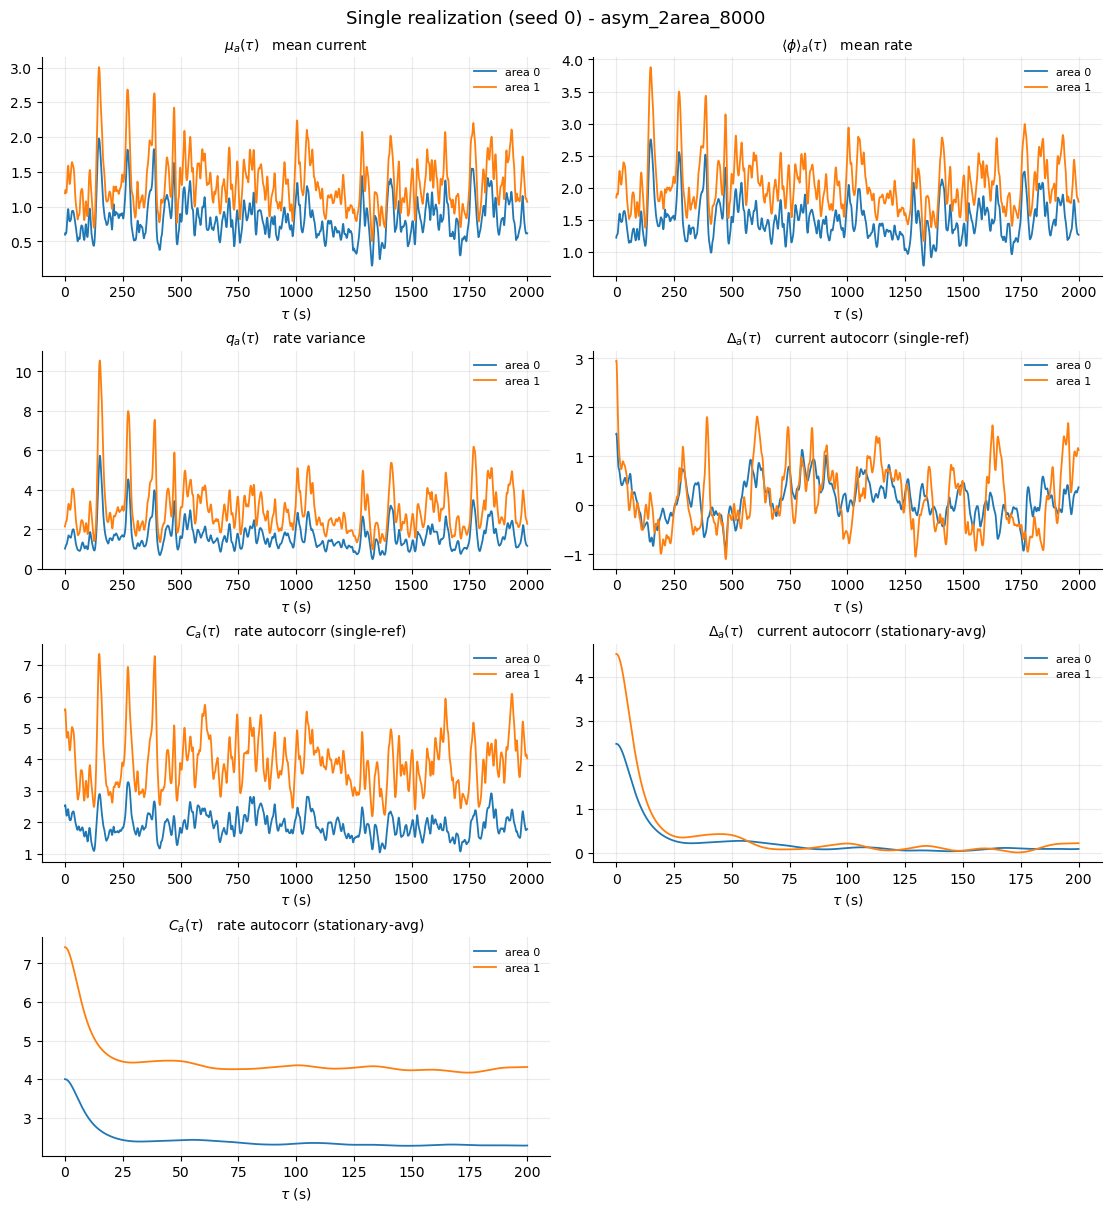

area 0: Delta(0)=1.46 (current var), C(0)=2.521 (<phi^2>), q(0)=1.029 (rate var), <phi>=1.222, mu=0.5974
area 1: Delta(0)=2.954 (current var), C(0)=5.563 (<phi^2>), q(0)=2.148 (rate var), <phi>=1.848, mu=1.192


In [7]:
# ============================================================
#  SINGLE REALIZATION  ->  run, save to disk, plot from disk
# ============================================================
out_dir = DATA_ROOT / run_name
ensure_meta(out_dir, p, run_name, sim_kwargs, n_realizations)

fpath0 = run_one(p, run_name, seed=10, sim_kwargs=sim_kwargs, force=False)

fig = plot_statistics_single(fpath0, title=f"Single realization (seed 0) - {run_name}")
fig.savefig(out_dir / "single_realization.png", dpi=110, bbox_inches="tight")
plt.show()

# quick sanity checks at tau = 0
_d = dict(np.load(fpath0))
for _a in range(int(_d["A"])):
    print(f"area {_a}: Delta(0)={_d['delta_sr'][0, _a]:.4g} (current var), "
          f"C(0)={_d['C_sr'][0, _a]:.4g} (<phi^2>), "
          f"q(0)={_d['q'][0, _a]:.4g} (rate var), "
          f"<phi>={_d['phi_mean'][0, _a]:.4g}, mu={_d['mu'][0, _a]:.4g}")

## 6. Many realizations — loop over seeds and average
Runs `n_realizations` seeds (skipping ones already on disk), then writes `averaged.npz` with the mean and std of every statistic across realizations.

In [34]:
# ============================================================
#  MULTIPLE REALIZATIONS  ->  loop over random seeds, average, save
#  Already-saved realizations are skipped (set force=True to recompute).
#  Each realization uses seed `s` for BOTH the connectivity and the
#  initial condition, so realizations are independent draws of the
#  same parameter set.
# ============================================================
avg_path = run_all_realizations(
    p, run_name, n_realizations, sim_kwargs, force=False
)
print("Averaged results at:", avg_path)

[run  ] realization seed=0 ...
  warmup done (20000 steps); max|x|=2.23
  recording  20.0%  max|x|=2.6
  recording  40.0%  max|x|=2.31
  recording  60.0%  max|x|=2.38
  recording  80.0%  max|x|=2.55
  recording 100.0%  max|x|=3.24
[saved] sym_2area/realization_00.npz
[run  ] realization seed=1 ...
  warmup done (20000 steps); max|x|=2.17
  recording  20.0%  max|x|=2.63
  recording  40.0%  max|x|=2.11
  recording  60.0%  max|x|=2.41
  recording  80.0%  max|x|=1.97
  recording 100.0%  max|x|=2.86
[saved] sym_2area/realization_01.npz
[run  ] realization seed=2 ...
  warmup done (20000 steps); max|x|=3.47
  recording  20.0%  max|x|=2.29
  recording  40.0%  max|x|=3.22
  recording  60.0%  max|x|=2.29
  recording  80.0%  max|x|=1.91
  recording 100.0%  max|x|=2.59
[saved] sym_2area/realization_02.npz
[run  ] realization seed=3 ...
  warmup done (20000 steps); max|x|=2.35
  recording  20.0%  max|x|=2.3
  recording  40.0%  max|x|=1.94
  recording  60.0%  max|x|=2.29
  recording  80.0%  max|x|=

## 7. Averaged plot — load and draw
Reads `averaged.npz` only; safe to re-run on its own to redraw the figure.

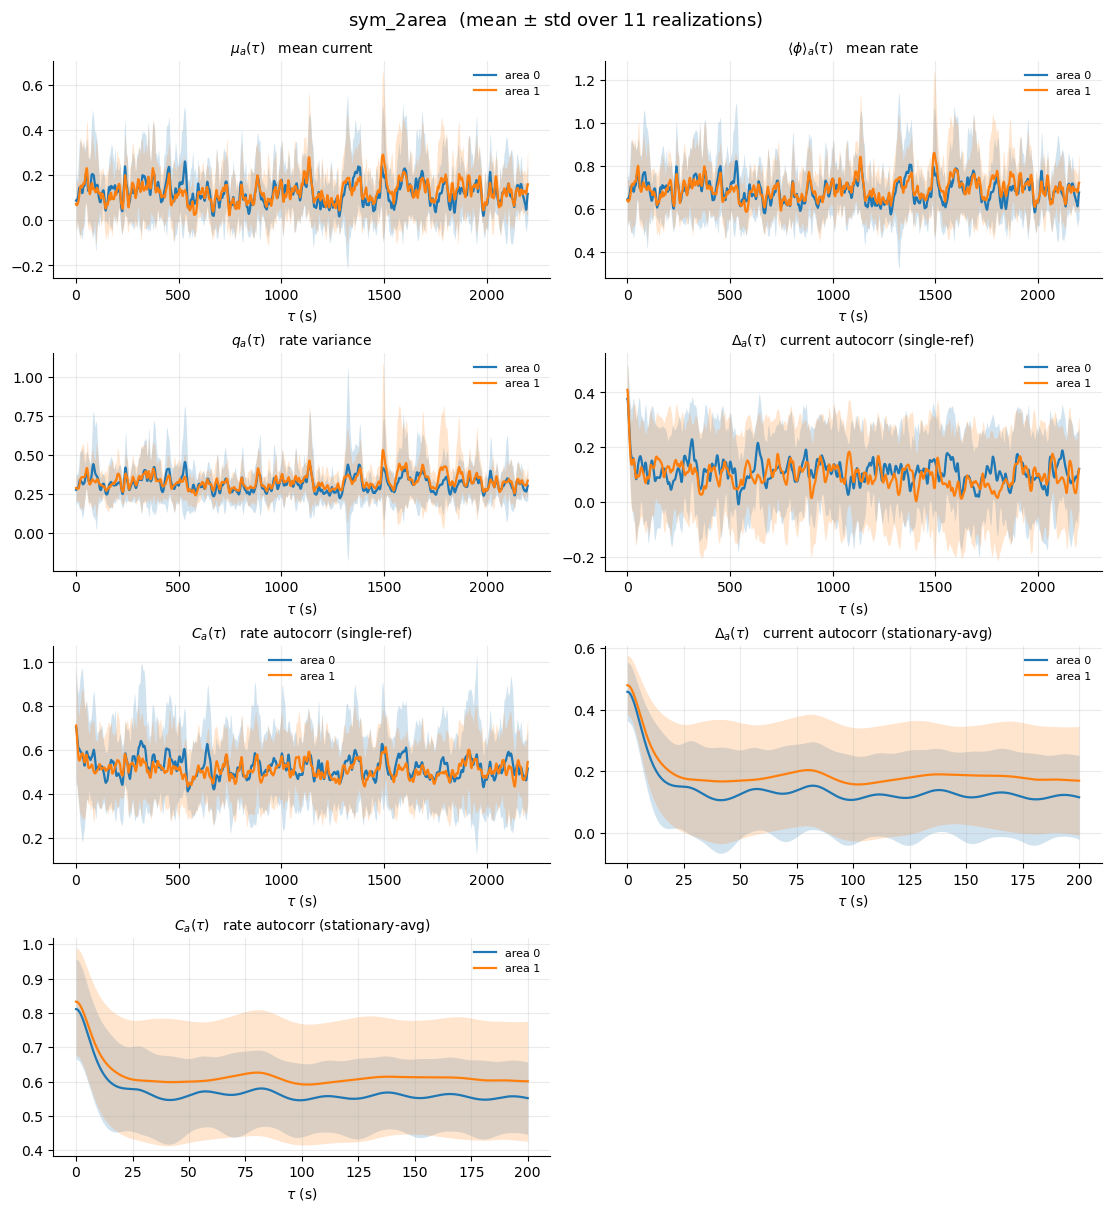

In [35]:
# ============================================================
#  AVERAGED PLOT  ->  load averaged.npz and plot (no re-simulation)
#  Re-run just this cell any time to redraw from the saved results.
# ============================================================
avg_path = DATA_ROOT / run_name / "averaged.npz"

fig = plot_statistics_averaged(avg_path, title=f"{run_name}")
fig.savefig(DATA_ROOT / run_name / "averaged.png", dpi=110, bbox_inches="tight")
plt.show()